# Categorical data Encoding

$ Technique
- For Nominal data -> One Hot Encoding
- For Ordinal data -> Ordinal Encoding
- For Target col -> Label Encoding 

# For Ordinal data

$ Label Encoding
- It is ONLY used when Target coln is Categorical

$ Ordinal Encoding
- Used when input colns are Categorical
- Here we need to assign numerical val for ordering

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
for i in range(3):
    print(i)
    i = 10

0
1
2


- If the loop iterates over a sequence/iterator → changing loop variable does NOT affect the loop.
- If the loop depends on a condition → changing loop variable DOES affect the loop.

In [15]:
df = pd.read_csv(r'C:\Users\HP\OneDrive\Desktop\python\pyCourse\csvFiles\customer.csv')

In [16]:
df.sample(5)

,age,gender,review,education,purchased
28,48,Male,Poor,School,No
47,38,Female,Good,PG,Yes
4,16,Female,Average,UG,No
29,83,Female,Average,UG,Yes
20,57,Female,Average,School,Yes


- Here, gender(one hot) & purchased(label) is nominal cols, review(ordinal) & educatn is ordinal categorical cols

In [17]:
df = df.iloc[:,2:]

In [18]:
df.head()

,review,education,purchased
0,Average,School,No
1,Poor,UG,No
2,Good,PG,No
3,Good,PG,No
4,Average,UG,No


In [22]:
# train test split
x_tr, x_ts, y_tr, y_ts = train_test_split(df.drop('purchased', axis=1), df['purchased'], test_size=0.3, random_state=0)

In [29]:
x_tr

,review,education
7,Poor,School
14,Poor,PG
45,Poor,PG
48,Good,UG
29,Average,UG
15,Poor,UG
30,Average,UG
32,Average,UG
16,Poor,UG
42,Good,PG


- Ordinal Encoding

In [23]:
from sklearn.preprocessing import OrdinalEncoder

In [30]:
oe = OrdinalEncoder(categories=[['Poor', 'Average', 'Good'], ['School', 'UG', 'PG']])

In [31]:
oe.fit(x_tr)

# transforing tr & ts
oe.transform(x_tr)
oe.transform(x_ts)

array([[0., 0.],
       [2., 1.],
       [2., 1.],
       [2., 2.],
       [2., 2.],
       [0., 2.],
       [2., 0.],
       [0., 0.],
       [0., 2.],
       [1., 1.],
       [2., 2.],
       [0., 0.],
       [0., 2.],
       [1., 0.],
       [2., 0.]])

In [33]:
oe.categories

[['Poor', 'Average', 'Good'], ['School', 'UG', 'PG']]

- Label Encoding

In [34]:
from sklearn.preprocessing import LabelEncoder

In [35]:
le = LabelEncoder()

In [39]:
le.fit(y_tr)

LabelEncoder()

In [40]:
le.classes_

array(['No', 'Yes'], dtype=object)

# For Nominal data

$ One-Hot Encoding
- As all classes in these cols weighs equal
- So we make separate cols for all classes

$ Dummy Variable Trap
- It occurs due to formation of n categorical cols which leads to multicollinarity

$ Multicollinarity : 
- Means removing one col as if we have n categories/classes in cols, so we take n-1 cols because in ml No Two Input cols should have dependency on each other.
So we remove one col, generally col1 or last

$ OHE using most frequent variables
- When we have many classes occurs most frequently and some not, then we do this
- In this we only consider the most freuent classes and treat them separate categories
- And rest non-frequent classes is combined to a new different class

In [41]:
datafr = pd.read_csv(r'C:\Users\HP\OneDrive\Desktop\python\pyCourse\csvFiles\cars.csv')

In [42]:
datafr.head()

,brand,km_driven,fuel,owner,selling_price
0,Maruti,145500,Diesel,First Owner,450000
1,Skoda,120000,Diesel,Second Owner,370000
2,Honda,140000,Petrol,Third Owner,158000
3,Hyundai,127000,Diesel,First Owner,225000
4,Maruti,120000,Petrol,First Owner,130000


In [46]:
datafr['brand'].value_counts()
datafr['brand'].nunique()

32

- OneHot Encoding using Pandas

In [48]:
pd.get_dummies(datafr, columns=['fuel', 'owner'])

,brand,km_driven,selling_price,fuel_CNG,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti,145500,450000,False,True,False,False,True,False,False,False,False
1,Skoda,120000,370000,False,True,False,False,False,False,True,False,False
2,Honda,140000,158000,False,False,False,True,False,False,False,False,True
3,Hyundai,127000,225000,False,True,False,False,True,False,False,False,False
4,Maruti,120000,130000,False,False,False,True,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,110000,320000,False,False,False,True,True,False,False,False,False
8124,Hyundai,119000,135000,False,True,False,False,False,True,False,False,False
8125,Maruti,120000,382000,False,True,False,False,True,False,False,False,False
8126,Tata,25000,290000,False,True,False,False,True,False,False,False,False


- K-1 OneHot Encding

In [49]:
pd.get_dummies(datafr, columns=['fuel', 'owner'], drop_first=True)

,brand,km_driven,selling_price,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti,145500,450000,True,False,False,False,False,False,False
1,Skoda,120000,370000,True,False,False,False,True,False,False
2,Honda,140000,158000,False,False,True,False,False,False,True
3,Hyundai,127000,225000,True,False,False,False,False,False,False
4,Maruti,120000,130000,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,110000,320000,False,False,True,False,False,False,False
8124,Hyundai,119000,135000,True,False,False,True,False,False,False
8125,Maruti,120000,382000,True,False,False,False,False,False,False
8126,Tata,25000,290000,True,False,False,False,False,False,False


- Pandas does not remember the order of classes distributn
- So we use sklearn module

$ OneHotEncoding using Sklearn

In [50]:
x_train, x_test, y_train, y_test = train_test_split(datafr.iloc[:,0:4], datafr.iloc[:,-1], test_size=0.3, random_state=0)

In [51]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
ohe = OneHotEncoder(drop='first', sparse_output=False)

In [67]:
x_train_new = ohe.fit_transform(x_train[['fuel','owner']])

In [68]:
x_test_new = ohe.transform(x_test[['fuel','owner']])

In [69]:
x_train_new.shape

(5689, 7)

In [70]:
np.hstack((x_train[['brand','km_driven']].values, x_train_new)).shape

(5689, 9)

<h1 style='color:red'># NUMERICAL DATA ENCODING</h1>

> <p style='color:gold'>Two techniques:</p>
1. Discretization/ Binning
2. Binarization

> <h4 style='color:pink'>Discretization :</h4>
- Discretizatn is the process of transforming continuous var into discrete var by creating a set of contiguous intervals that span the range of the var value. It is also called binning, where bin is an alternative name for interval
- In this we simply divide our numerical data into categories for better understanding and plot them into Histogram

> Why to use:
1. To handle outliers
2. To improve the value spread

> Types of Binning :
1. Unsupervised -> 3 subtype: Equal width(uniform), Equal freq(quantile), k-means bining
2. Supervised -> Decision tree binning
3. Custom Binning

> Equal Width :
- Means by defining no of bins, we can make equal no of intervals of data where we assign the freq of data in intervals and then plot using hist
- Formula : (max - min) / bins
- this tells what is the length of interval
- Take ON : 
1. Handles outliers as outline val comes in last bin treating it equal
2. No change in spread of data

> Equal Freq :
- In this we assign no of intervals as n and each interval will contain 'n' percentile values
- Ex: let interval = 10, then each interval contains 10% of total obs. So therefore, intervals : 0-16;16-20;20-22;22-25;.....
- TAkE ON : 
1. Handle Outliers
2. Reduce val spread

> k-Means :
- When data is in form of clusters
- In this we make interval/centroid anywhere between clusters and then calculate distance of data to each interval and put data into nearest one and then move centroid in the cluster to the mean of that cluster and then Repeat the whole process again & again until current and prev one process result become same

> <h5 style='color:green'>> How to apply?</h5>
- sklearn -> kBinsDiscretizer(bins, strategy(uniform,quantile,k-means), encoding(ordinal,onehot))

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [2]:
df = pd.read_csv(r'C:\Users\HP\OneDrive\Desktop\python\pyCourse\csvFiles\titanic\train.csv', usecols=['Age','Fare','Survived'])

In [3]:
df.dropna(inplace=True)

In [4]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [5]:
a = df.iloc[:,1:]
b = df.iloc[:,0]

In [6]:
a_tr, a_ts, b_tr, b_ts = train_test_split(a,b, test_size=0.2, random_state=42)

In [7]:
clf = DecisionTreeClassifier()
clf.fit(a_tr, b_tr)
b_pred = clf.predict(a_ts)

In [8]:
accuracy_score(b_ts, b_pred)

0.6223776223776224

In [9]:
np.mean(cross_val_score(DecisionTreeClassifier(), a,b, scoring='accuracy', cv=10))

np.float64(0.6289123630672926)

In [10]:
kbin_age = KBinsDiscretizer(n_bins=10, encode='ordinal',strategy='quantile')
kbin_fare = KBinsDiscretizer(n_bins=10, encode='ordinal',strategy='quantile')

In [14]:
trf = ColumnTransformer([
    ('first', kbin_age, [0]),
    ('scnd', kbin_fare, [1])
])

In [15]:
a_tr_trf = trf.fit_transform(a_tr)
a_ts_trf = trf.fit_transform(a_ts)

C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current defaul

In [18]:
trf.named_transformers_['first'].n_bins_

array([10])

In [19]:
trf.named_transformers_['first'].bin_edges_

array([array([ 1. , 11. , 17. , 20.6, 24. , 28. , 30.1, 34.4, 38.6, 47.8, 62. ])],
      dtype=object)

- Now checking on transformed data

In [21]:
clf = DecisionTreeClassifier()
clf.fit(a_tr_trf, b_tr)
b_pred_trf = clf.predict(a_ts_trf)
accuracy_score(b_ts, b_pred_trf)

0.6853146853146853

- A Function for using Descretizatn

In [28]:
def discretizatn(bins, strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins, encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins, encode='ordinal',strategy=strategy)

    trf = ColumnTransformer([
        ('first', kbin_age, [0]),
        ('scnd', kbin_fare, [1])
    ])

    a_trf = trf.fit_transform(a)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),a,b, cv=10, scoring='accuracy')))

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(a['Age'])
    plt.title('Before')

    plt.subplot(122)
    plt.hist(a_trf[:,0], color='red')
    plt.title('After')

    plt.show()

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(a['Fare'])
    plt.title('Before')

    plt.subplot(122)
    plt.hist(a_trf[:,1], color='blue')
    plt.title('After')

    plt.show()

0.6331181533646322


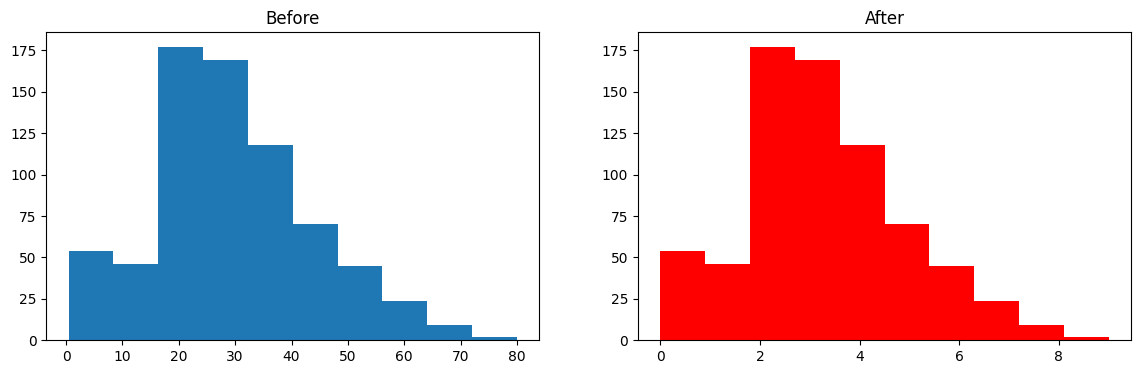

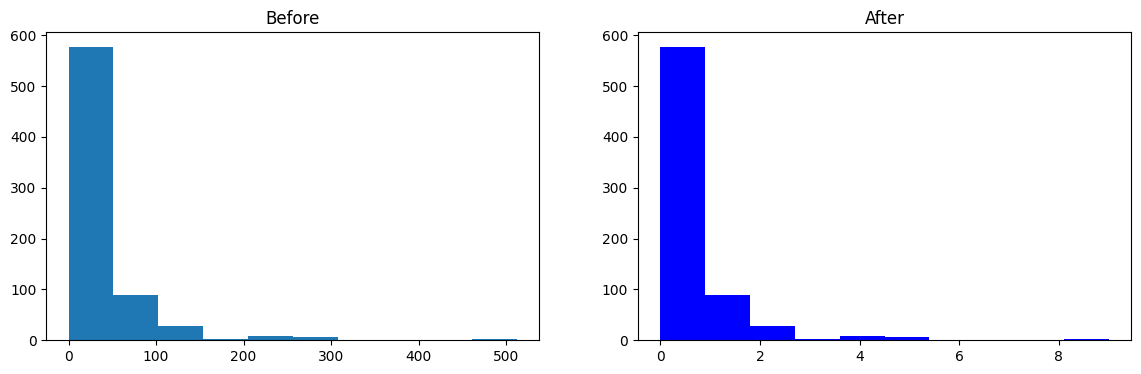

In [30]:
discretizatn(10, 'uniform')

> Binarization
- It converts the numerical values into binary(0 & 1) 

> How to apply:
- Load the fn
- Apply trf on loaded fn
- transform the train & test data
- Now train the model on that transform data